In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
mpl.style.use('ggplot')

In [4]:
hospital_data = pd.read_csv(r"D:\Time serise & Survival analysis\Time series analysis data\HDHI Admission data2.csv")

In [9]:
hospital_data.head()

,SNO,MRD No.,D.O.A,D.O.D,AGE,GENDER,RURAL,TYPE OF ADMISSION-EMERGENCY/OPD,month year,DURATION OF STAY,...,CONGENITAL,UTI,NEURO CARDIOGENIC SYNCOPE,ORTHOSTATIC,INFECTIVE ENDOCARDITIS,DVT,CARDIOGENIC SHOCK,SHOCK,PULMONARY EMBOLISM,CHEST INFECTION
0,1,234735,4/1/2017,4/3/2017,81,M,R,E,17-Apr,3,...,0,0,0,0,0,0,0,0,0,0
1,2,234696,4/1/2017,4/5/2017,65,M,R,E,17-Apr,5,...,0,0,0,0,0,0,0,0,0,0
2,3,234882,4/1/2017,4/3/2017,53,M,U,E,17-Apr,3,...,0,0,0,0,0,0,0,0,0,0
3,4,234635,4/1/2017,4/8/2017,67,F,U,E,17-Apr,8,...,0,0,0,0,0,0,0,0,0,0
4,5,234486,4/1/2017,4/23/2017,60,F,U,E,17-Apr,23,...,0,0,0,0,0,0,0,0,0,0


In [8]:
hospital_data.shape

(13360, 56)

In [7]:
variables = ["D.O.A","TYPE OF ADMISSION-EMERGENCY/OPD","SNO"]

In [11]:
group_variables = variables[:2]
outcome_variable = variables[2]
date_data = hospital_data.groupby(group_variables)[outcome_variable].count().reset_index()

In [12]:
date_data.head(5)

,D.O.A,TYPE OF ADMISSION-EMERGENCY/OPD,SNO
0,1/1/2018,E,34
1,1/1/2018,O,16
2,1/10/2017,E,1
3,1/10/2017,O,1
4,1/10/2018,E,14


In [9]:
date_data.index

RangeIndex(start=0, stop=1569, step=1)

In [10]:
date_data.dtypes

D.O.A                              object
TYPE OF ADMISSION-EMERGENCY/OPD    object
SNO                                 int64
dtype: object

In [11]:
date_data["D.O.A"]= date_data["D.O.A"].astype("datetime64[s]")

In [12]:
date_data.dtypes

D.O.A                              datetime64[s]
TYPE OF ADMISSION-EMERGENCY/OPD           object
SNO                                        int64
dtype: object

In [13]:
date_data.head()

,D.O.A,TYPE OF ADMISSION-EMERGENCY/OPD,SNO
0,2018-01-01,E,34
1,2018-01-01,O,16
2,2017-01-10,E,1
3,2017-01-10,O,1
4,2018-01-10,E,14


In [14]:
print(date_data["TYPE OF ADMISSION-EMERGENCY/OPD"].unique())

['E' 'O']


In [15]:
date_data = date_data.rename(columns={"D.O.A":"Date of Admission"})
date_data = date_data.rename(columns={"SNO":"Patient Count"})

In [16]:
date_data.head()

,Date of Admission,TYPE OF ADMISSION-EMERGENCY/OPD,Patient Count
0,2018-01-01,E,34
1,2018-01-01,O,16
2,2017-01-10,E,1
3,2017-01-10,O,1
4,2018-01-10,E,14


In [17]:
date_data = date_data.sort_values("Date of Admission")

In [18]:
date_data.set_index("Date of Admission",inplace=True)

In [19]:
date_data.head()

,TYPE OF ADMISSION-EMERGENCY/OPD,Patient Count
Date of Admission,,
2017-01-04,O,1
2017-01-10,E,1
2017-01-10,O,1
2017-01-11,O,2
2017-01-12,O,3


In [20]:
print(date_data[date_data["TYPE OF ADMISSION-EMERGENCY/OPD"]=="E"]["2018":"2019"].head())

                  TYPE OF ADMISSION-EMERGENCY/OPD  Patient Count
Date of Admission                                               
2018-01-01                                      E             34
2018-01-02                                      E             25
2018-01-03                                      E              8
2018-01-04                                      E             16
2018-01-05                                      E             15


In [21]:
date_data.reset_index(inplace=True)

In [22]:
categorical_data = date_data.groupby(['Date of Admission', 'TYPE OF ADMISSION-EMERGENCY/OPD'])['Patient Count'].sum().unstack(fill_value=0)

In [23]:
print(categorical_data["2017":].head())

TYPE OF ADMISSION-EMERGENCY/OPD  E  O
Date of Admission                    
2017-01-04                       0  1
2017-01-10                       1  1
2017-01-11                       0  2
2017-01-12                       8  3
2017-02-04                       2  0


In [24]:
categorical_data.columns.name = None
categorical_data.head()

,E,O
Date of Admission,,
2017-01-04,0,1
2017-01-10,1,1
2017-01-11,0,2
2017-01-12,8,3
2017-02-04,2,0


In [25]:
print('No. of Unique dates',len(categorical_data.index.unique()),'Days')
Data_range =categorical_data.index.max()-categorical_data.index.min()
print("Data Range",Data_range.days,'Days')

No. of Unique dates 651 Days
Data Range 726 Days


In [26]:
new_index= pd.date_range(categorical_data.index.min(),categorical_data.index.max())
print(new_index)

DatetimeIndex(['2017-01-04', '2017-01-05', '2017-01-06', '2017-01-07',
               '2017-01-08', '2017-01-09', '2017-01-10', '2017-01-11',
               '2017-01-12', '2017-01-13',
               ...
               '2018-12-22', '2018-12-23', '2018-12-24', '2018-12-25',
               '2018-12-26', '2018-12-27', '2018-12-28', '2018-12-29',
               '2018-12-30', '2018-12-31'],
              dtype='datetime64[ns]', length=727, freq='D')


In [27]:
New_index_data = categorical_data.reindex(new_index,fill_value=0)

In [28]:
New_index_data.index

DatetimeIndex(['2017-01-04', '2017-01-05', '2017-01-06', '2017-01-07',
               '2017-01-08', '2017-01-09', '2017-01-10', '2017-01-11',
               '2017-01-12', '2017-01-13',
               ...
               '2018-12-22', '2018-12-23', '2018-12-24', '2018-12-25',
               '2018-12-26', '2018-12-27', '2018-12-28', '2018-12-29',
               '2018-12-30', '2018-12-31'],
              dtype='datetime64[ns]', length=727, freq='D')

In [29]:
New_index_data.head()

,E,O
2017-01-04,0,1
2017-01-05,0,0
2017-01-06,0,0
2017-01-07,0,0
2017-01-08,0,0


In [30]:
Weekly_data = New_index_data.resample('W').sum()

In [31]:
Weekly_data.head()

,E,O
2017-01-08,0,1
2017-01-15,9,6
2017-01-22,0,0
2017-01-29,0,0
2017-02-05,2,0


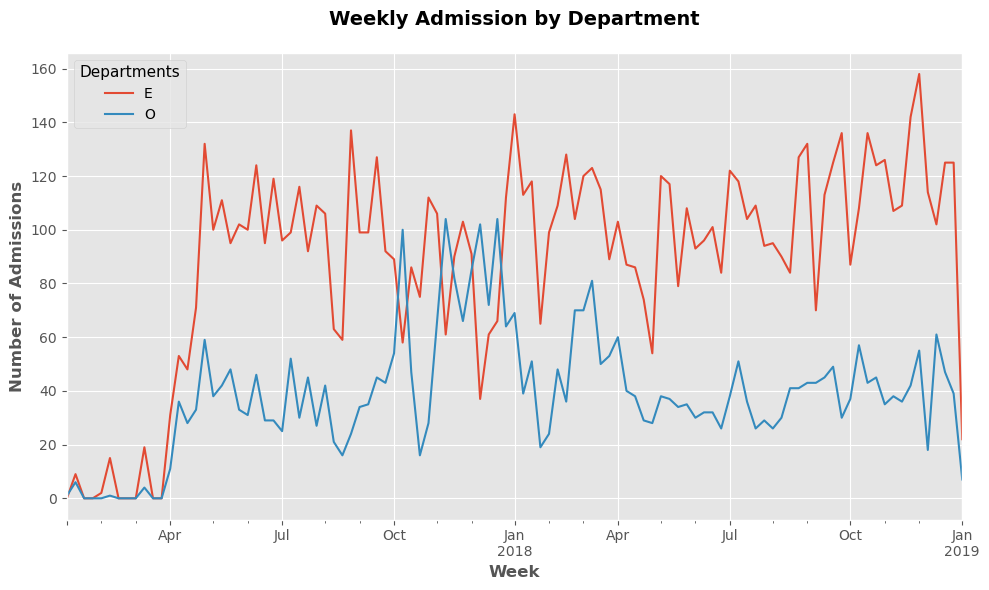

In [32]:
Weekly_data.plot(figsize =(10,6), title= 'Weekly Admission by department')
plt.xlabel('Week', fontsize=12, fontweight='bold')
plt.ylabel('Number of Admissions', fontsize=12, fontweight='bold')
plt.title('Weekly Admission by Department', fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Departments', fontsize=10, title_fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [33]:
Monthly_data = New_index_data.resample('ME').sum()
Monthly_data.head()

,E,O
2017-01-31,9,7
2017-02-28,17,1
2017-03-31,19,4
2017-04-30,335,167
2017-05-31,441,173


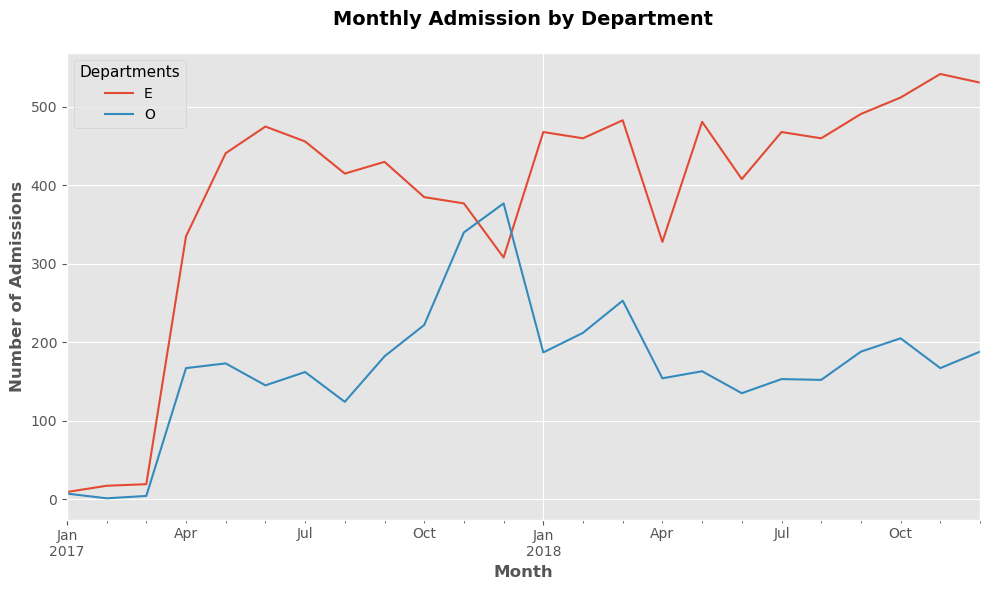

In [34]:
Monthly_data.plot(figsize =(10,6))
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Number of Admissions', fontsize=12, fontweight='bold')
plt.title('Monthly Admission by Department', fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Departments', fontsize=10, title_fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [35]:
Quarter_data = New_index_data.resample('QE').sum()
Quarter_data.head()

,E,O
2017-03-31,45,12
2017-06-30,1251,485
2017-09-30,1301,468
2017-12-31,1070,939
2018-03-31,1411,652


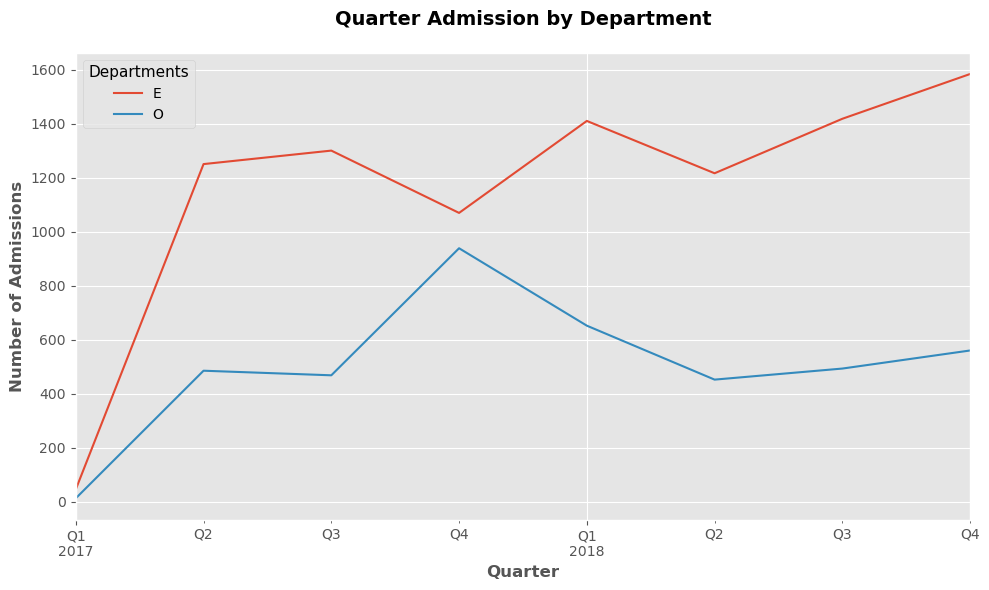

In [36]:
Quarter_data.plot(figsize =(10,6))
plt.xlabel('Quarter', fontsize=12, fontweight='bold')
plt.ylabel('Number of Admissions', fontsize=12, fontweight='bold')
plt.title('Quarter Admission by Department', fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Departments', fontsize=10, title_fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [37]:
Yearly_data = New_index_data.resample('YE').sum()
Yearly_data.head()

,E,O
2017-12-31,3667,1904
2018-12-31,5632,2157


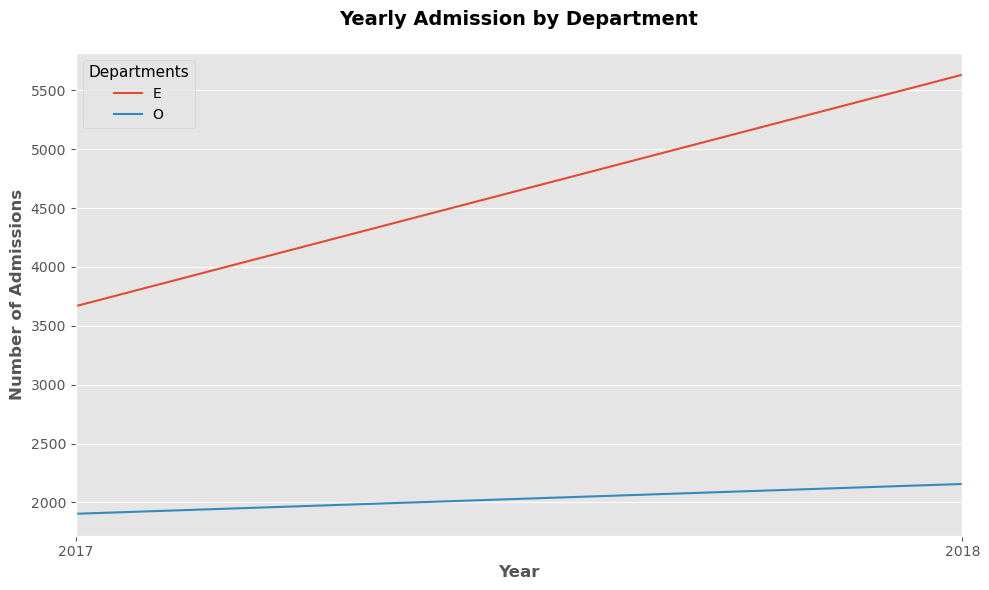

In [38]:
Yearly_data.plot(figsize =(10,6))
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Admissions', fontsize=12, fontweight='bold')
plt.title('Yearly Admission by Department', fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Departments', fontsize=10, title_fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [39]:
# Percent change Monthly
Monthly_change =Monthly_data.pct_change()

In [40]:
# Percent change Yearly
Yearly_change = Yearly_data.pct_change()
Quarter_change = Quarter_data.pct_change()

In [41]:
Monthly_data.join(Monthly_data.pct_change().add_suffix('_%_change')).head()

,E,O,E_%_change,O_%_change
2017-01-31,9,7,NaN,NaN
2017-02-28,17,1,0.888889,-0.857143
2017-03-31,19,4,0.117647,3.000000
2017-04-30,335,167,16.631579,40.750000
2017-05-31,441,173,0.316418,0.035928


In [42]:
Window_size = 7
rolling_window = New_index_data.rolling(Window_size)
print('Rolling Mean')
print(rolling_window.mean().dropna().head())
print('Rolling Standard deviation')
print(rolling_window.std().dropna().head())
rolling_std =rolling_window.std()
print('Rolling Varience')
print(rolling_window.var().dropna().head())
print('Cumulative Admission')
print(New_index_data.cumsum().dropna().tail())
cumulative_weekly_Admission=New_index_data.cumsum()

Rolling Mean
                   E         O
2017-01-10  0.142857  0.285714
2017-01-11  0.142857  0.428571
2017-01-12  1.285714  0.857143
2017-01-13  1.285714  0.857143
2017-01-14  1.285714  0.857143
Rolling Standard deviation
                   E         O
2017-01-10  0.377964  0.487950
2017-01-11  0.377964  0.786796
2017-01-12  2.984085  1.214986
2017-01-13  2.984085  1.214986
2017-01-14  2.984085  1.214986
Rolling Varience
                   E         O
2017-01-10  0.142857  0.238095
2017-01-11  0.142857  0.619048
2017-01-12  8.904762  1.476190
2017-01-13  8.904762  1.476190
2017-01-14  8.904762  1.476190
Cumulative Admission
               E     O
2018-12-27  9220  4041
2018-12-28  9238  4047
2018-12-29  9258  4054
2018-12-30  9277  4054
2018-12-31  9299  4061


<Axes: title={'center': 'Daily Admission Standard Deviation, 7-day Rolling Average'}>

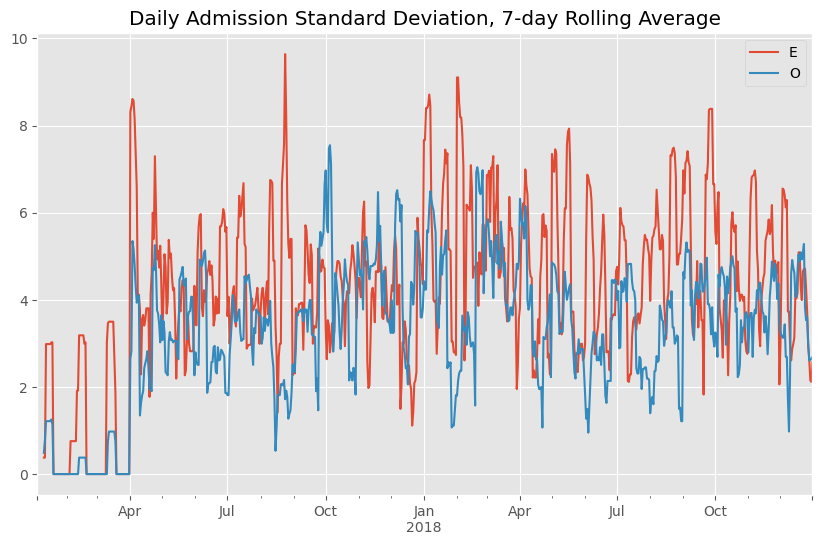

In [43]:
rolling_std.plot(figsize=(10,6), title='Daily Admission Standard Deviation, 7-day Rolling Average')

<Axes: title={'center': 'Monthly Admission % Change'}>

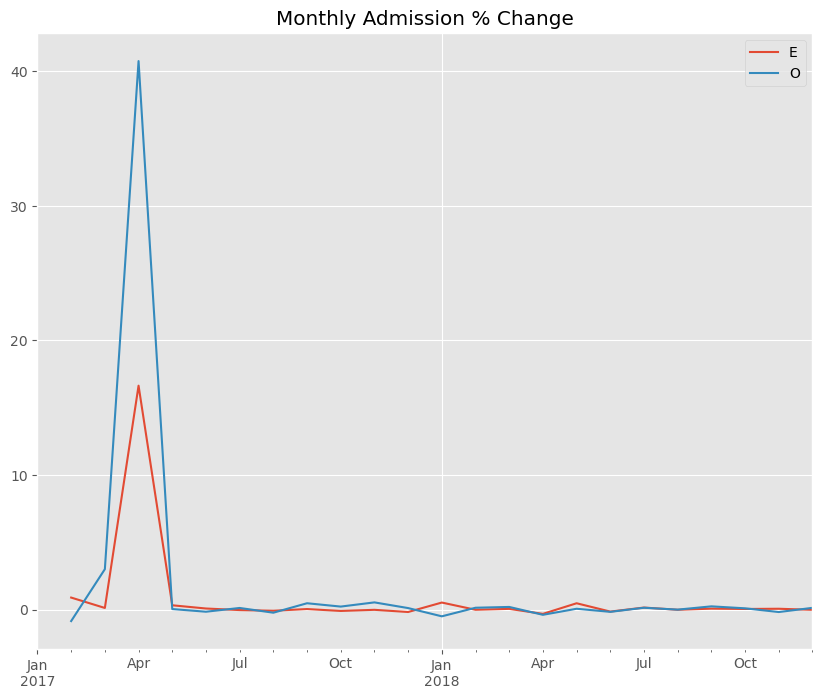

In [44]:
Monthly_change.plot(figsize=(10,8), title='Monthly Admission % Change')

<Axes: title={'center': 'Quarter Admission % Change'}>

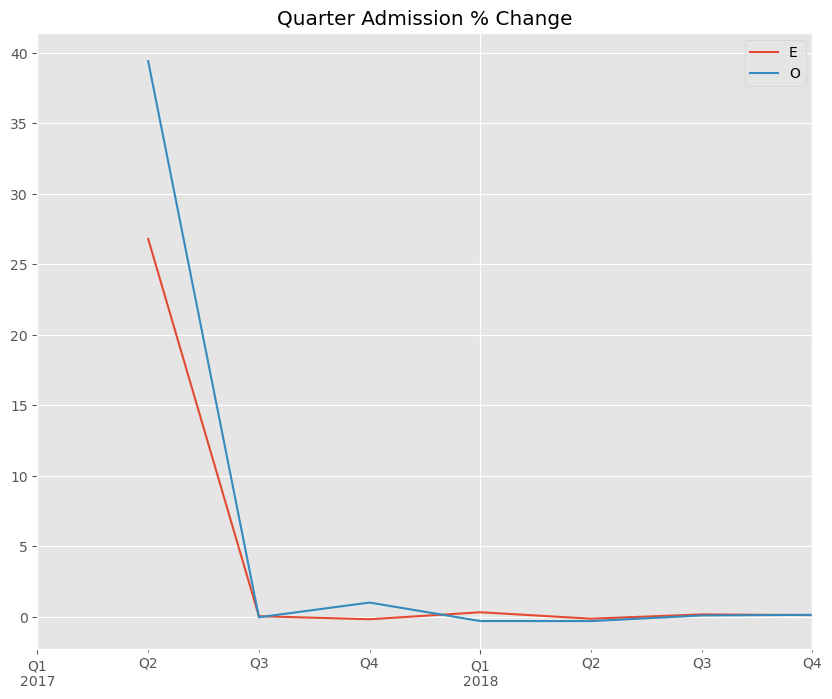

In [45]:
Quarter_change.plot(figsize=(10,8), title='Quarter Admission % Change')

<Axes: title={'center': 'Cumulative Weekly Admission'}>

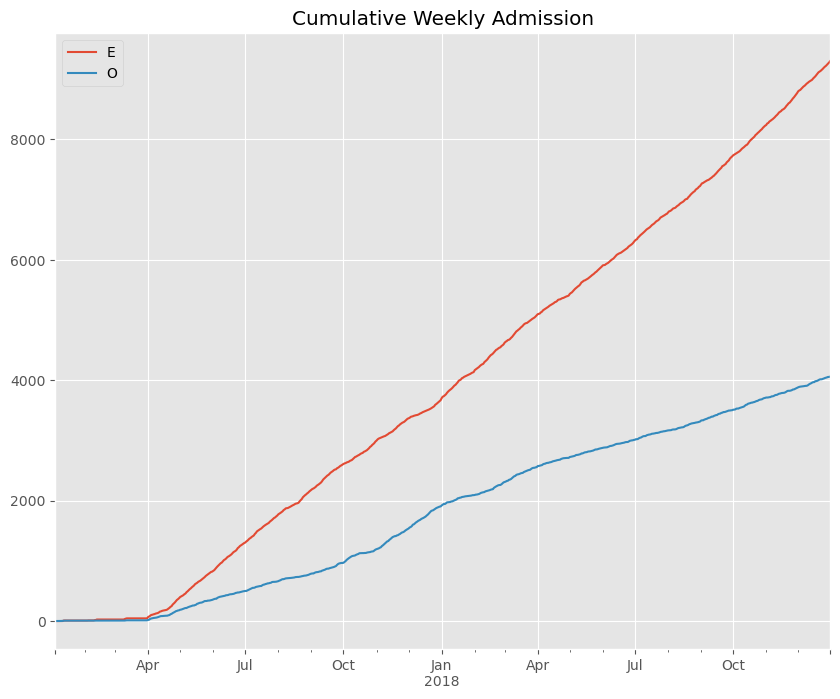

In [46]:
cumulative_weekly_Admission.plot(figsize=(10,8), title='Cumulative Weekly Admission')

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot,quarter_plot

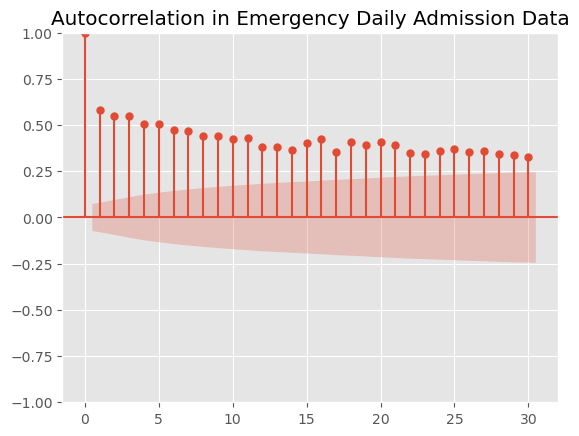

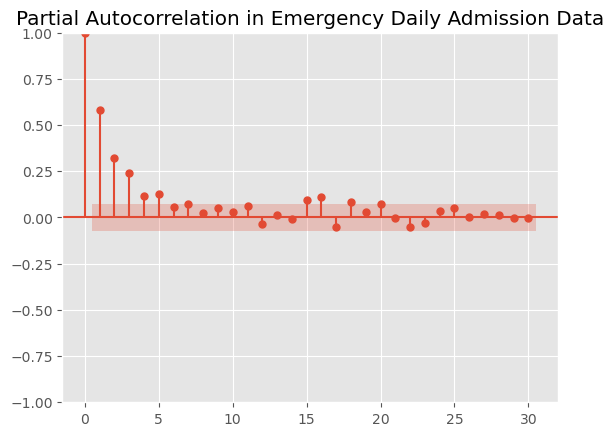

In [48]:
acf_emergency_plot = plot_acf(New_index_data["E"],lags=30, title='Autocorrelation in Emergency Daily Admission Data')
pacf_emergency_plot = plot_pacf(New_index_data["E"],lags=30, title='Partial Autocorrelation in Emergency Daily Admission Data')

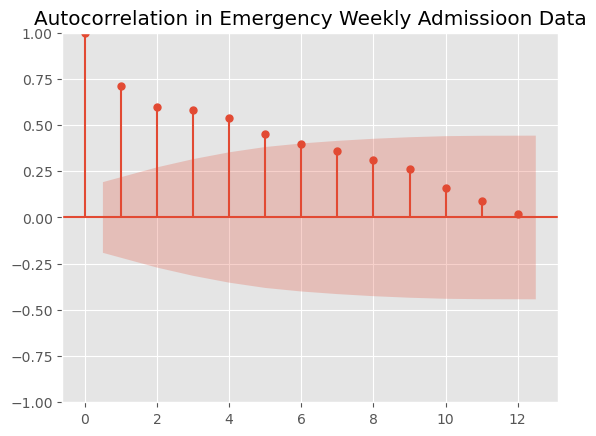

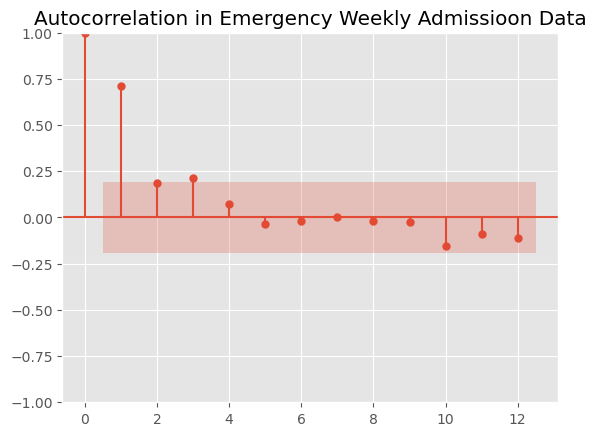

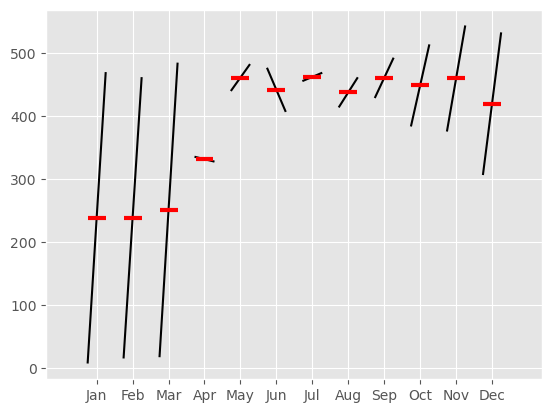

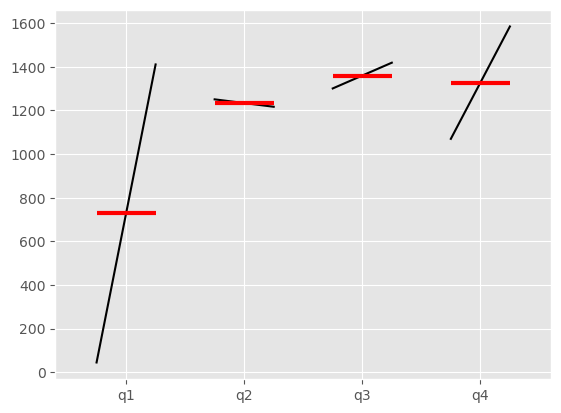

In [49]:
acf_weekly_emergency_plot = plot_acf(Weekly_data["E"],lags = 12, title='Autocorrelation in Emergency Weekly Admissioon Data')
pacf_weekly_emergency_plot = plot_pacf(Weekly_data["E"],lags = 12, title='Autocorrelation in Emergency Weekly Admissioon Data')
m_plot = month_plot(Monthly_data['E'])
q_plot = quarter_plot(Quarter_data['E'])

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [51]:
decomp_add_E = seasonal_decompose(New_index_data['E'],model='additive',period = 7,extrapolate_trend='freq')

In [52]:
estimated_trend1 = decomp_add_E.trend
estimated_seasonal1 = decomp_add_E.seasonal
estimated_residual1= decomp_add_E.resid

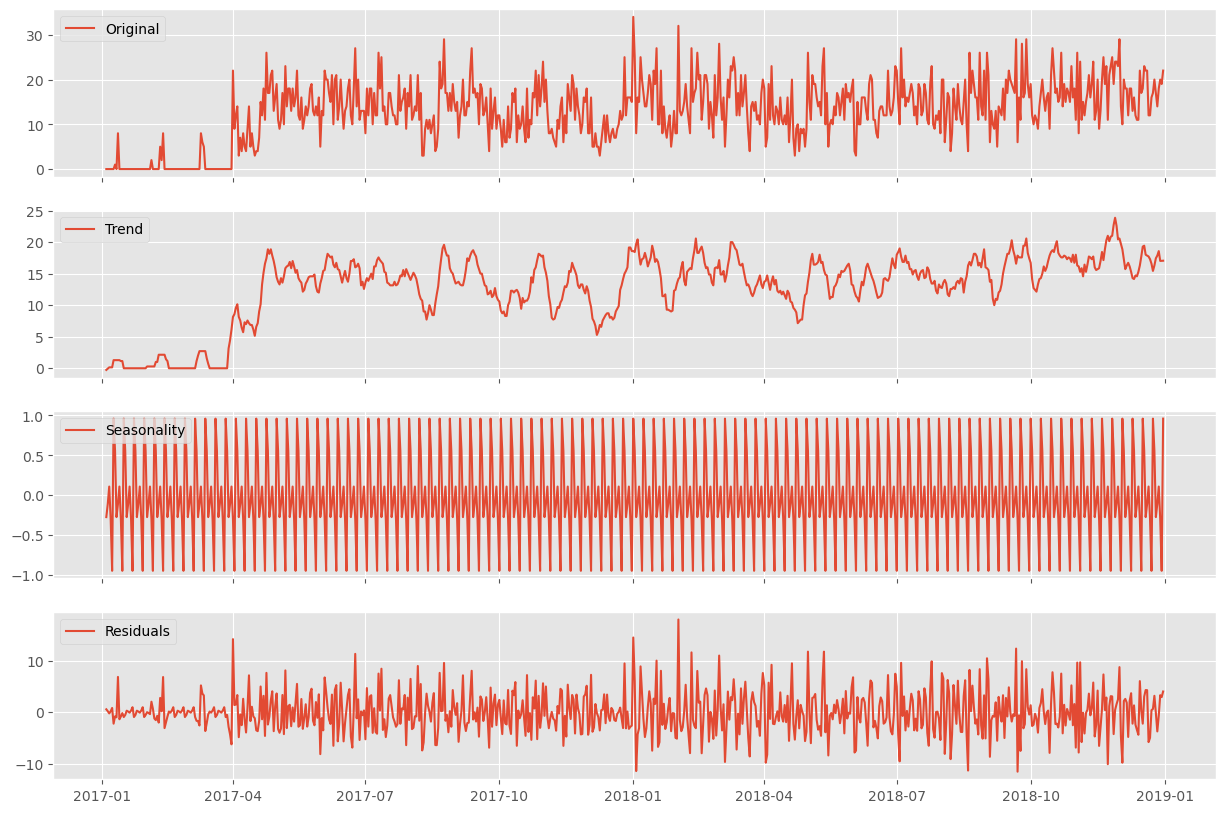

In [53]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(New_index_data['E'], label='Original')
axes[0].legend(loc='upper left');

axes[1].plot(estimated_trend1, label='Trend')
axes[1].legend(loc='upper left');

axes[2].plot(estimated_seasonal1, label='Seasonality')
axes[2].legend(loc='upper left');

axes[3].plot(estimated_residual1, label='Residuals')
axes[3].legend(loc='upper left');

In [54]:
residual_array = estimated_residual1.to_numpy()

In [55]:
chunks = np.array_split(residual_array,indices_or_sections=10)

In [56]:
chunks_mean = [np.mean(chunk) for chunk in chunks]
print(chunks_mean)

[0.006254736636239588, 0.013653771065607404, -0.06304142945518697, 0.037037004759507046, 0.02213751830937709, -0.02725327932040517, 0.015684700090414234, -0.014536978773157468, -0.01128619929469902, 0.12749912252633866]


In [57]:
chunks_var = [np.var(chunk) for chunk in chunks]
print(chunks_var)

[3.176166033245652, 12.074356788696205, 18.360289159805728, 13.117997462585825, 15.65568091892286, 25.933599631731127, 19.354425444738215, 21.038366442993727, 22.514879802399335, 18.365465061523352]


<Axes: >

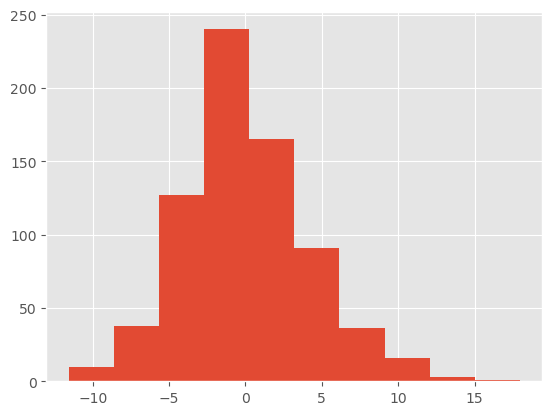

In [58]:
pd.Series(estimated_residual1).hist()

In [59]:
from statsmodels.tsa.stattools import adfuller

In [60]:
residual_clean = estimated_residual1.replace([np.inf, -np.inf], np.nan).dropna()

In [61]:
adf_stat, p_value, usedlag, nobs, critical_values, icbest = adfuller(residual_clean)

In [62]:
print('adf stat' , adf_stat)
print('p_value' , p_value)
print('critical_values' , critical_values)

adf stat -12.918582649134676
p_value 3.918141358450324e-24
critical_values {'1%': -3.439620010600208, '5%': -2.8656309041017756, '10%': -2.5689484851894413}


In [63]:
from statsmodels.tsa.seasonal import STL

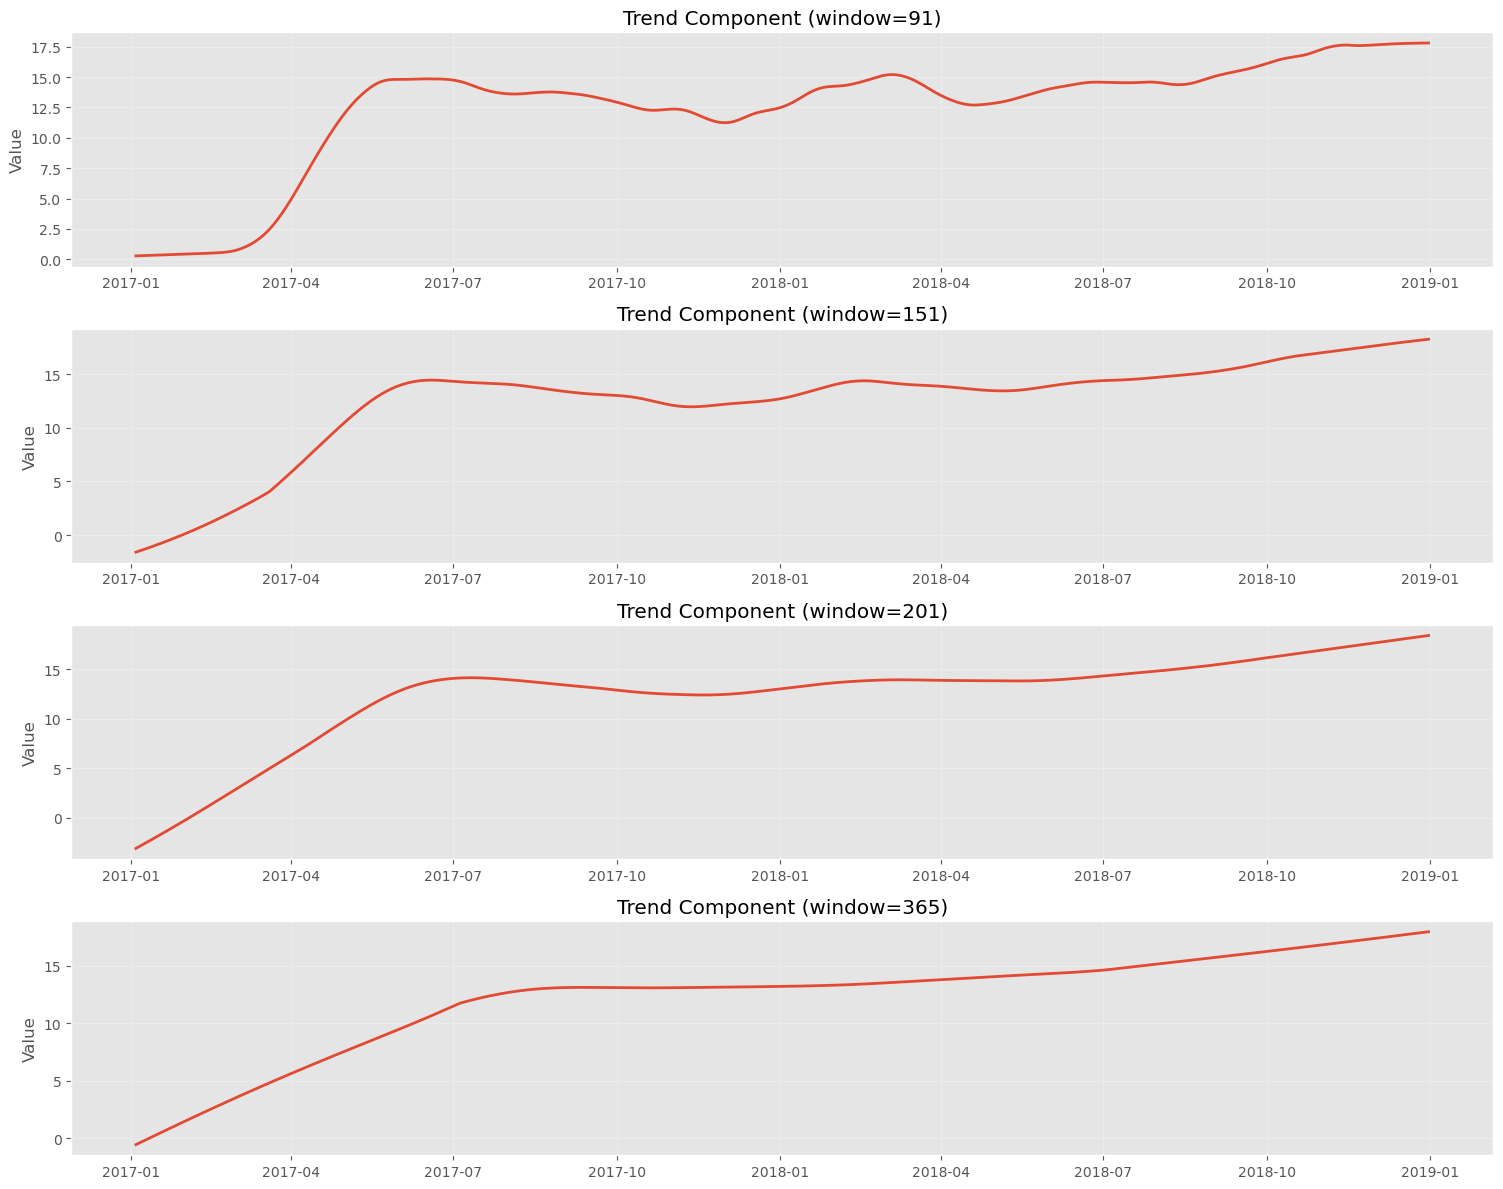

In [64]:
trend_windows =[91,151,201,365]
fig,axes=plt.subplots(4,1,figsize = (15,12))

for idx, window in enumerate(trend_windows):    
    stl = STL(New_index_data['E'], seasonal=13, trend=window, robust=True)
    result = stl.fit()
    axes[idx].plot(result.trend, linewidth=2)
    axes[idx].set_title(f'Trend Component (window={window})')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

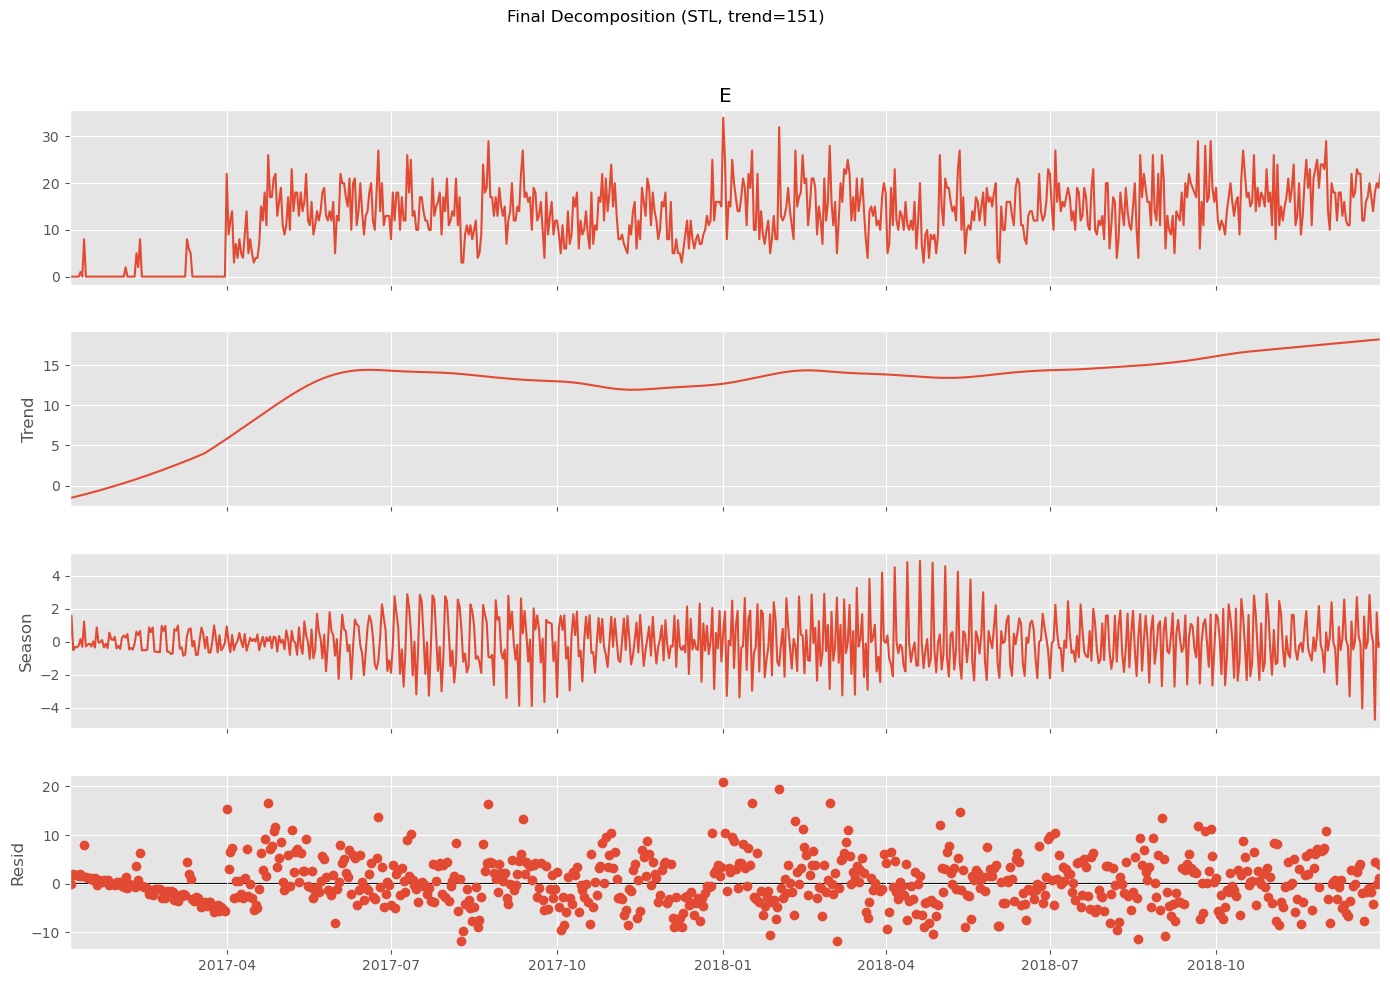

In [65]:
# Best decomposition
stl = STL(New_index_data['E'], seasonal=13, trend=151, robust=True)
result = stl.fit()

# Extract components
estimated_trend = result.trend
estimated_seasonal = result.seasonal
estimated_residual = result.resid


# Plot decomposition
fig = result.plot()
fig.set_size_inches(15, 10) 
plt.suptitle('Final Decomposition (STL, trend=151)', y=1.02)
plt.show()

In [66]:
residual_clean = estimated_residual.replace([np.inf, -np.inf], np.nan).dropna()

adf_stat, p_value, usedlag, nobs, critical_values, icbest = adfuller(residual_clean)

print(f'ADF Statistic: {adf_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print('Critical Values:')
for key, val in critical_values.items():
    print(f'   {key}: {val:.4f}')

if p_value < 0.05:
    print('\n✅ Residuals are STATIONARY — ready for ARIMA')
else:
    print('\n❌ Residuals are NOT stationary — need differencing')

ADF Statistic: -6.2398
p-value: 0.0000
Critical Values:
   1%: -3.4396
   5%: -2.8656
   10%: -2.5690

✅ Residuals are STATIONARY — ready for ARIMA


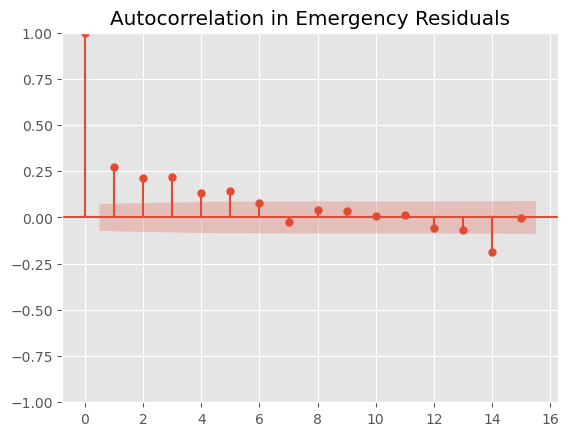

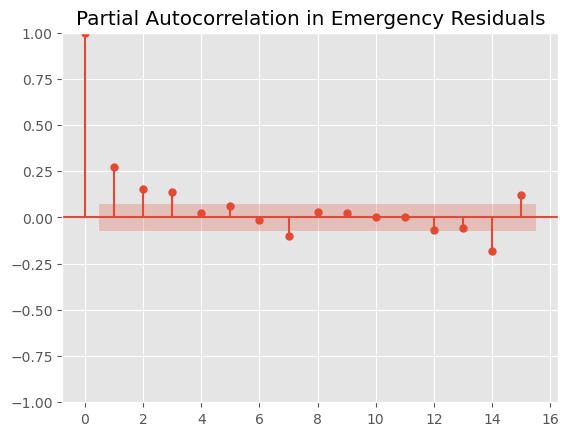

In [67]:
fig_acf = plot_acf(residual_clean,lags = 15, title='Autocorrelation in Emergency Residuals')
fig_pacf = plot_pacf(residual_clean,lags = 15, title='Partial Autocorrelation in Emergency Residuals')

In [68]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(residual_clean, order=(3, 0, 1))
arima_result = model.fit()


print(arima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  727
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -2140.175
Date:                Thu, 21 May 2026   AIC                           4292.349
Time:                        07:04:18   BIC                           4319.883
Sample:                    01-04-2017   HQIC                          4302.974
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3452      0.360      0.959      0.338      -0.360       1.051
ar.L1          0.4916      0.223      2.203      0.028       0.054       0.929
ar.L2          0.0548      0.066      0.830      0.4

In [69]:
from pmdarima import auto_arima

auto_model1 = auto_arima(residual_clean,
                        start_p=0, max_p=4,
                        start_q=0, max_q=4,
                        start_P=0, max_P=2,
                        start_Q=0, max_Q=2,
                        seasonal=False,
                        d=0,           # ← already stationary
                        D=0,           # ← no forced seasonal differencing
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True,
                        information_criterion='aic')

# ← Note the () at the end
print(auto_model1.summary())
print(f"\nBest AIC: {auto_model1.aic():.4f}")
print(f"Best model order: {auto_model1.order}")
print(f"Seasonal order:   {auto_model1.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4374.376, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=4318.355, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4331.909, Time=0.13 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=4302.885, Time=0.17 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=4290.410, Time=0.38 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=4291.967, Time=0.46 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=4291.382, Time=0.72 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=4291.903, Time=0.60 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=4293.318, Time=0.81 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=4291.270, Time=0.87 sec

Best model:  ARIMA(3,0,0)(0,0,0)[0]          
Total fit time: 4.351 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  727
Model:               SARIMAX(3, 0, 0)   Log Likelihood        

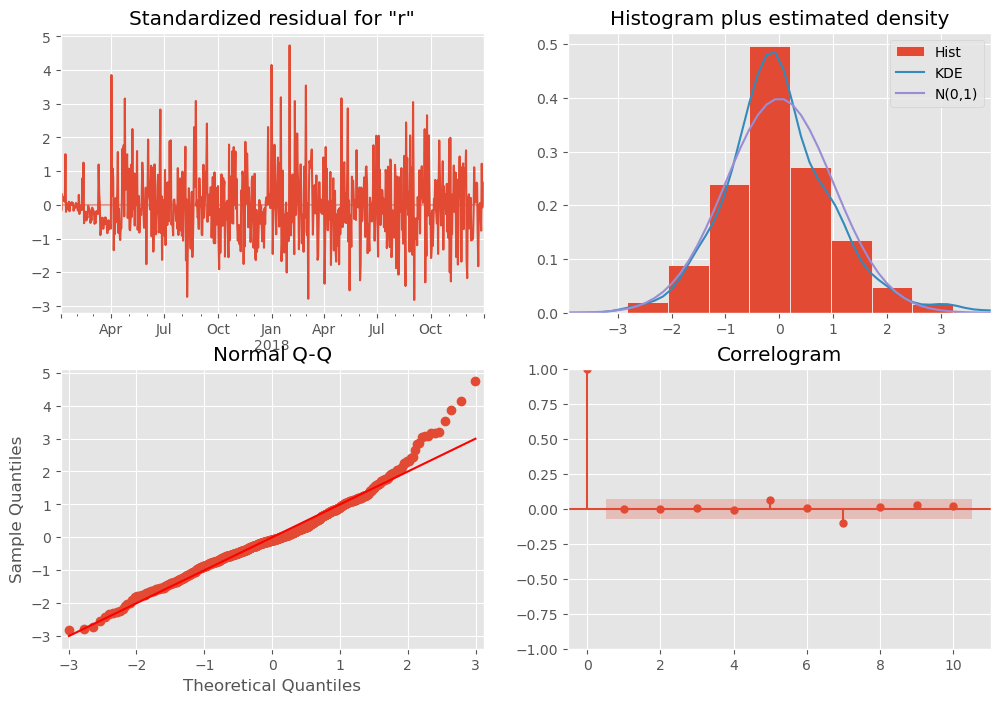

In [70]:
arima_result.plot_diagnostics(figsize=(12, 8))
plt.show()

In [71]:
# Refit without intercept (cleaner model)
arima_result = ARIMA(residual_clean, 
                     order=(3, 0, 0),
                     trend='n').fit()  # 'n' = no constant
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  727
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -2141.205
Date:                Thu, 21 May 2026   AIC                           4290.410
Time:                        07:04:32   BIC                           4308.766
Sample:                    01-04-2017   HQIC                          4297.493
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2125      0.037      5.690      0.000       0.139       0.286
ar.L2          0.1211      0.035      3.481      0.000       0.053       0.189
ar.L3          0.1402      0.036      3.885      0.0

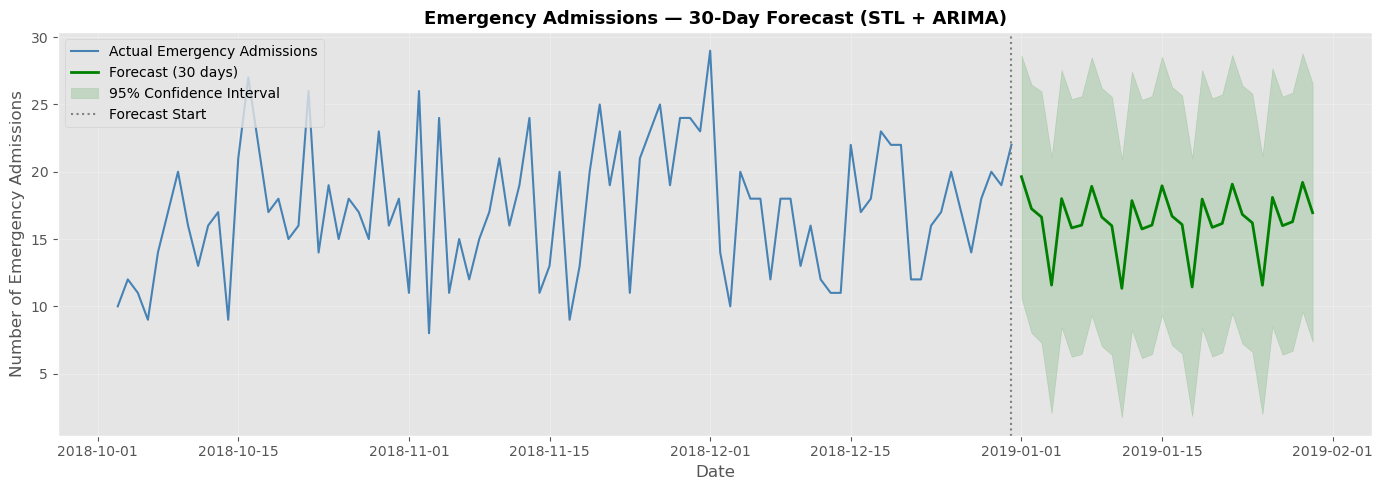


📋 30-Day Forecast:
            Forecast  Lower 95%  Upper 95%
2019-01-01      19.6       10.6       28.7
2019-01-02      17.3        8.0       26.5
2019-01-03      16.6        7.3       26.0
2019-01-04      11.6        2.1       21.1
2019-01-05      18.0        8.5       27.6
2019-01-06      15.8        6.3       25.4
2019-01-07      16.0        6.5       25.6
2019-01-08      18.9        9.3       28.5
2019-01-09      16.6        7.0       26.2
2019-01-10      16.0        6.4       25.6
2019-01-11      11.3        1.7       20.9
2019-01-12      17.9        8.3       27.4
2019-01-13      15.7        6.2       25.3
2019-01-14      16.0        6.4       25.6
2019-01-15      19.0        9.4       28.5
2019-01-16      16.7        7.1       26.3
2019-01-17      16.1        6.5       25.7
2019-01-18      11.4        1.8       21.0
2019-01-19      18.0        8.4       27.6
2019-01-20      15.9        6.3       25.5
2019-01-21      16.2        6.6       25.8
2019-01-22      19.1        9.5   

In [72]:
# ── Step 1: Regenerate preds ──────────────────────────────────────────────────
def future_preds_df(arima_result, stl_result, series, num_days):
    
    future_index = pd.date_range(
        start   = series.index.max() + pd.Timedelta(days=1),
        periods = num_days,
        freq    = 'D'
    )

    forecast_obj = arima_result.get_forecast(steps=num_days)
    arima_preds  = forecast_obj.predicted_mean.values
    conf_int     = forecast_obj.conf_int(alpha=0.05)

    x      = np.arange(len(stl_result.trend))
    x_fut  = np.arange(len(stl_result.trend), len(stl_result.trend) + num_days)
    coeffs = np.polyfit(x[-60:], stl_result.trend.values[-60:], deg=2)
    trend_forecast = np.polyval(coeffs, x_fut)

    season_period     = 7
    seasonal_forecast = np.tile(
        stl_result.seasonal.values[-season_period:],
        int(np.ceil(num_days / season_period))
    )[:num_days]

    full_forecast = trend_forecast + seasonal_forecast + arima_preds
    full_lower    = trend_forecast + seasonal_forecast + conf_int.iloc[:, 0].values
    full_upper    = trend_forecast + seasonal_forecast + conf_int.iloc[:, 1].values

    return pd.DataFrame({
        'Forecast':  full_forecast,
        'Lower 95%': full_lower,
        'Upper 95%': full_upper
    }, index=future_index)


# ── Step 2: Run it ────────────────────────────────────────────────────────────
preds = future_preds_df(arima_result, result, New_index_data['E'], num_days=30)

# ── Step 3: Apply bias correction ─────────────────────────────────────────────
bias = -2.42
preds['Forecast']   = preds['Forecast']   + bias
preds['Lower 95%']  = preds['Lower 95%']  + bias
preds['Upper 95%']  = preds['Upper 95%']  + bias

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(New_index_data['E'].iloc[-90:],
        color='steelblue', linewidth=1.5,
        label='Actual Emergency Admissions')

ax.plot(preds['Forecast'],
        color='green', linewidth=2,
        label='Forecast (30 days)')

ax.fill_between(preds.index,
                preds['Lower 95%'],
                preds['Upper 95%'],
                color='green', alpha=0.15,
                label='95% Confidence Interval')

ax.axvline(x=New_index_data['E'].index[-1],
           color='gray', linestyle=':',
           linewidth=1.5, label='Forecast Start')

ax.set_title('Emergency Admissions — 30-Day Forecast (STL + ARIMA)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Emergency Admissions')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 30-Day Forecast:")
print(preds.round(1))

In [76]:
from prophet import Prophet

In [77]:
df_prophet = pd.DataFrame({
    'ds': New_index_data['2017-04':].index,
    'y' : New_index_data['2017-04':]['E'].values
})
    
print(df_prophet.head())

          ds   y
0 2017-04-01  22
1 2017-04-02   9
2 2017-04-03  12
3 2017-04-04  14
4 2017-04-05   3


In [78]:
m = Prophet()
m.fit(df_prophet)

07:04:54 - cmdstanpy - INFO - Chain [1] start processing
07:04:55 - cmdstanpy - INFO - Chain [1] done processing


In [79]:
future = m.make_future_dataframe(periods=90)
print(future.head())
print(future.tail())

          ds
0 2017-04-01
1 2017-04-02
2 2017-04-03
3 2017-04-04
4 2017-04-05
            ds
725 2019-03-27
726 2019-03-28
727 2019-03-29
728 2019-03-30
729 2019-03-31


In [80]:
forecast = m.predict(future)
print(forecast.columns)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')


,ds,yhat,yhat_lower,yhat_upper
725,2019-03-27,17.588413,10.595330,24.154473
726,2019-03-28,17.724392,10.737514,24.139427
727,2019-03-29,17.959262,10.470670,24.652022
728,2019-03-30,17.405326,10.473201,24.230105
729,2019-03-31,16.670343,10.047350,23.911804


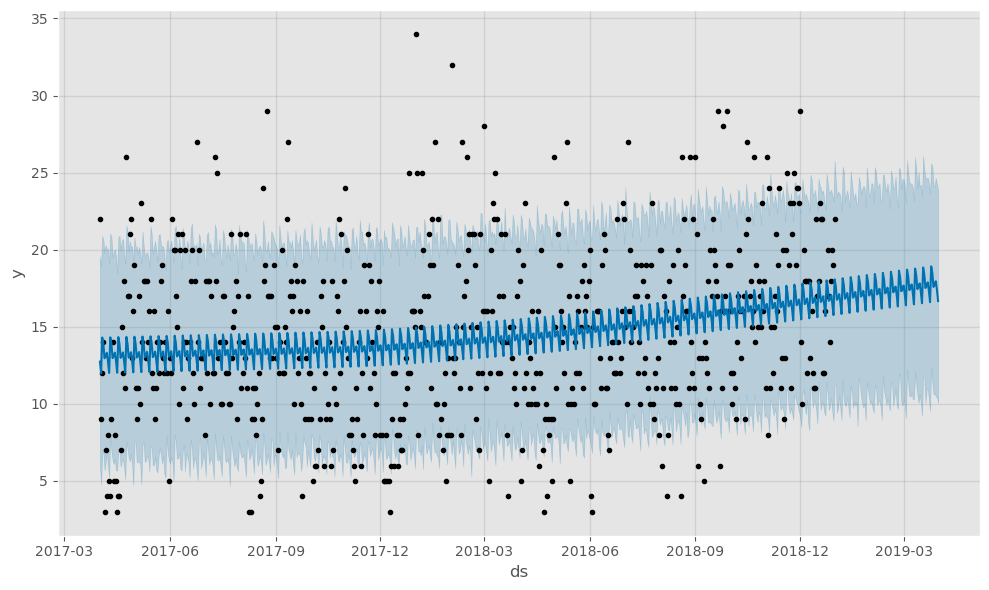

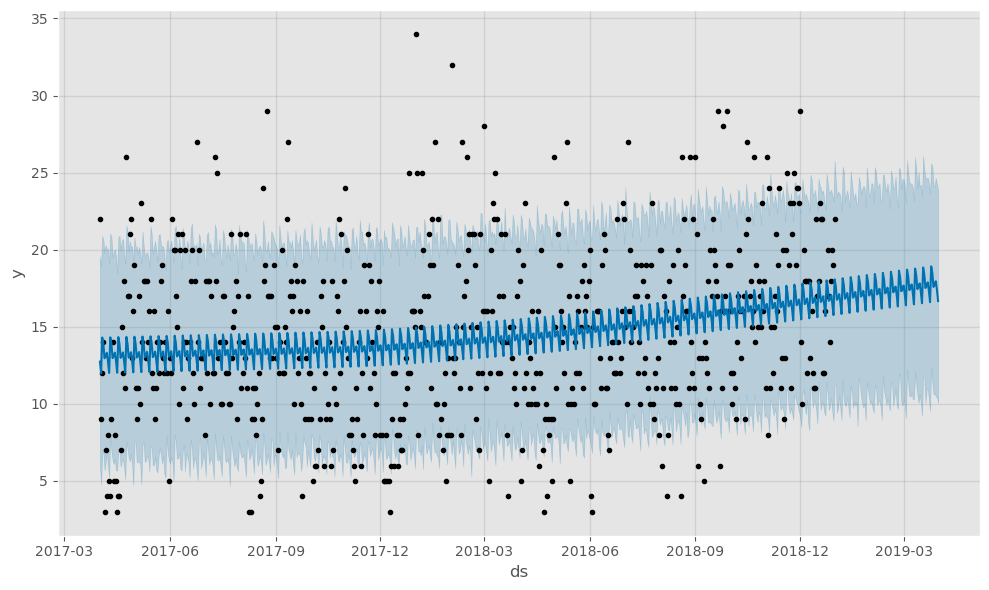

In [81]:
m.plot(forecast)

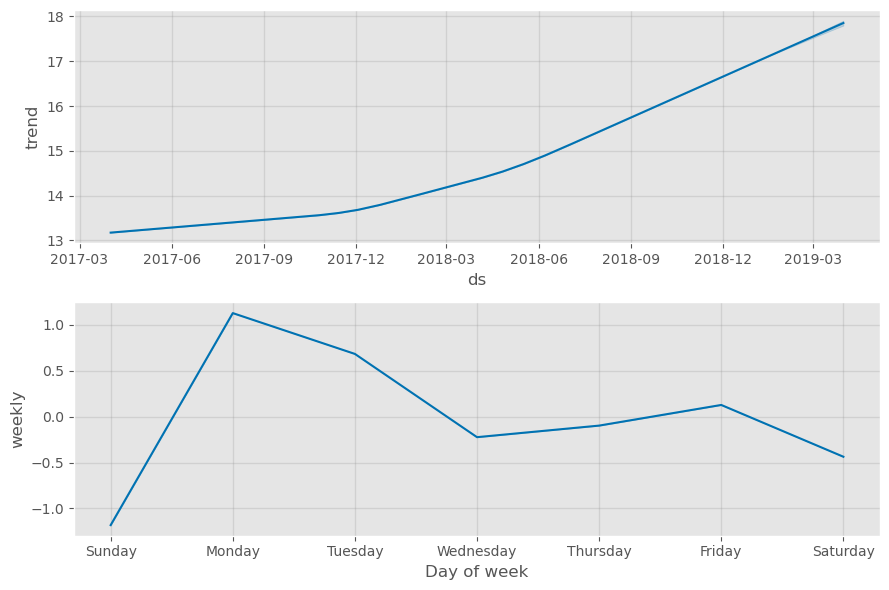

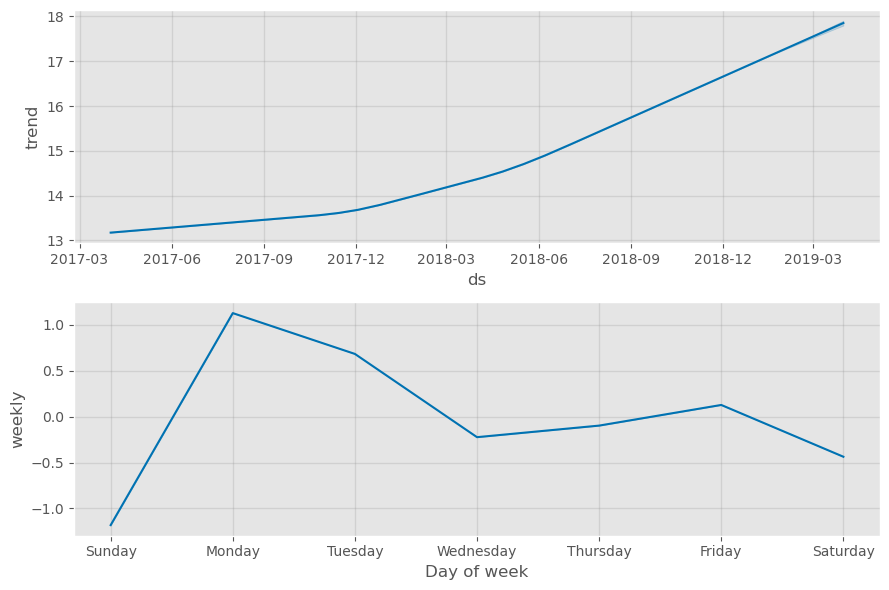

In [82]:
m.plot_components(forecast)

In [88]:
from prophet.diagnostics import cross_validation

In [91]:
#Starting from 730 days in, making a prediction every 30 days, 90 days into the future
df_cv = cross_validation(m, initial='365 days', period='30 days', horizon = '90 days')
df_cv.head()

  0%|          | 0/7 [00:00<?, ?it/s]

07:14:54 - cmdstanpy - INFO - Chain [1] start processing
07:14:55 - cmdstanpy - INFO - Chain [1] done processing
07:14:55 - cmdstanpy - INFO - Chain [1] start processing
07:14:55 - cmdstanpy - INFO - Chain [1] done processing
07:14:55 - cmdstanpy - INFO - Chain [1] start processing
07:14:55 - cmdstanpy - INFO - Chain [1] done processing
07:14:55 - cmdstanpy - INFO - Chain [1] start processing
07:14:55 - cmdstanpy - INFO - Chain [1] done processing
07:14:56 - cmdstanpy - INFO - Chain [1] start processing
07:14:56 - cmdstanpy - INFO - Chain [1] done processing
07:14:56 - cmdstanpy - INFO - Chain [1] start processing
07:14:56 - cmdstanpy - INFO - Chain [1] done processing
07:14:56 - cmdstanpy - INFO - Chain [1] start processing
07:14:56 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2018-04-06,13.819825,6.956408,20.570967,23,2018-04-05
1,2018-04-07,14.162215,7.038075,21.234307,12,2018-04-05
2,2018-04-08,13.275356,6.225618,20.259411,10,2018-04-05
3,2018-04-09,15.827924,8.204084,22.990610,14,2018-04-05
4,2018-04-10,14.997739,8.201064,21.870142,13,2018-04-05


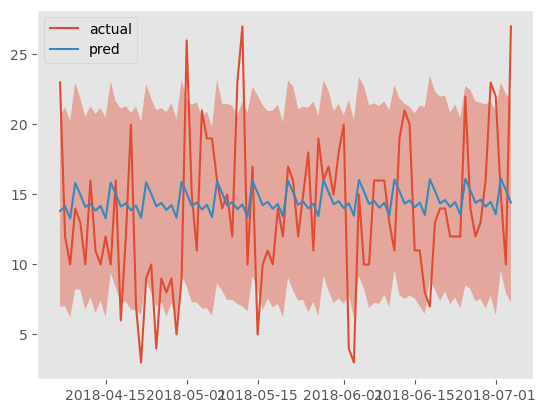

In [95]:
from datetime import datetime
first_cut = df_cv[df_cv.cutoff == datetime(2018,4,5)]
plt.plot(first_cut.ds,first_cut.y,label='actual')
plt.plot(first_cut.ds,first_cut.yhat,label = 'pred')
plt.fill_between(first_cut.ds,first_cut.yhat_lower,first_cut.yhat_upper,alpha=0.4)
plt.grid()
plt.legend()

In [98]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,9 days,21.168264,4.600898,3.634983,0.326447,0.225983,0.265770,0.888889
1,10 days,18.978563,4.356439,3.360302,0.309648,0.194068,0.247558,0.904762
2,11 days,19.301554,4.393353,3.424134,0.322752,0.197900,0.255514,0.904762
3,12 days,20.025246,4.474958,3.570247,0.332375,0.225983,0.265152,0.904762
4,13 days,19.000545,4.358961,3.514812,0.305618,0.228449,0.257360,0.904762


In [99]:
df_p.tail()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
77,86 days,31.415905,5.604989,4.391419,0.251399,0.199322,0.262987,0.777778
78,87 days,35.649335,5.970706,4.821780,0.275680,0.229538,0.288012,0.730159
79,88 days,31.040095,5.571364,4.489325,0.261370,0.229075,0.271536,0.761905
80,89 days,32.262363,5.679997,4.588184,0.251434,0.213110,0.271938,0.761905
81,90 days,37.519233,6.125295,4.950060,0.280235,0.251766,0.295072,0.746032


In [100]:
# ── Final 90-day forecast summary table ───────────────────────────────────────
future   = m.make_future_dataframe(periods=90)
forecast = m.predict(future)

# ── Keep future dates only ────────────────────────────────────────────────────
future_only = forecast[forecast['ds'] > df_prophet['ds'].max()]

# ── Clean summary table ───────────────────────────────────────────────────────
summary_table = future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
summary_table.columns = ['Date', 'Forecast', 'Lower 95%', 'Upper 95%']
summary_table = summary_table.round(1).reset_index(drop=True)

print("📋 90-Day Emergency Admission Forecast:")
print(summary_table.to_string())

📋 90-Day Emergency Admission Forecast:
         Date  Forecast  Lower 95%  Upper 95%
0  2019-01-01      17.6       11.1       24.2
1  2019-01-02      16.8        9.6       23.6
2  2019-01-03      16.9       10.0       23.8
3  2019-01-04      17.1       10.3       24.2
4  2019-01-05      16.6        9.7       23.3
5  2019-01-06      15.8        8.1       22.5
6  2019-01-07      18.2       11.1       25.1
7  2019-01-08      17.7       10.5       24.9
8  2019-01-09      16.8       10.1       24.2
9  2019-01-10      17.0       10.2       23.7
10 2019-01-11      17.2       10.4       24.7
11 2019-01-12      16.6       10.0       23.6
12 2019-01-13      15.9        9.0       22.7
13 2019-01-14      18.2       11.2       24.8
14 2019-01-15      17.8       11.0       24.4
15 2019-01-16      16.9       10.6       23.9
16 2019-01-17      17.0       10.4       24.1
17 2019-01-18      17.3       10.0       23.9
18 2019-01-19      16.7        9.6       23.8
19 2019-01-20      16.0        9.4       

In [101]:
print("=" * 50)
print("      FINAL MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"\n{'Model':<20} {'MAE':>8} {'RMSE':>8} {'sMAPE':>8}")
print("-" * 50)
print(f"{'STL + ARIMA(3,0,0)':<20} {'4.61':>8} {'5.80':>8} {'30.75%':>8}")
print(f"{'Prophet (90 days)':<20} {'4.95':>8} {'6.13':>8} {'29.5%':>8}")
print("-" * 50)
print("\n✅ Selected Model: Prophet")
print("   Reason: Better long-horizon performance,")
print("           handles seasonality automatically,")
print("           easier to maintain and explain")
print("\n📋 Forecast horizon: 90 days")
print(f"📅 Forecast period:  Jan 2019 → Mar 2019")
print(f"📊 Avg daily forecast: ~{summary_table['Forecast'].mean():.1f} admissions")
print(f"📊 Range: {summary_table['Forecast'].min():.1f} – {summary_table['Forecast'].max():.1f} admissions/day")

      FINAL MODEL COMPARISON SUMMARY

Model                     MAE     RMSE    sMAPE
--------------------------------------------------
STL + ARIMA(3,0,0)       4.61     5.80   30.75%
Prophet (90 days)        4.95     6.13    29.5%
--------------------------------------------------

✅ Selected Model: Prophet
   Reason: Better long-horizon performance,
           handles seasonality automatically,
           easier to maintain and explain

📋 Forecast horizon: 90 days
📅 Forecast period:  Jan 2019 → Mar 2019
📊 Avg daily forecast: ~17.4 admissions
📊 Range: 15.8 – 18.9 admissions/day
